<a href="https://colab.research.google.com/github/danishsuryarirta-create/UAS_Bengkel_Koding/blob/main/UAS_Churn_Prediction_A11202314873.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# UAS Bengkel Koding Data Science

# Danish Suryarirta Kusuma Yudha
# A11.2023.14873

# Prediksi Churn Pelanggan — Sales & Marketing Customer Dataset

---
## 📋 Struktur Notebook
1. **EDA** — Eksplorasi & Validasi Data
2. **Direct Modeling** — Baseline tanpa preprocessing
3. **Modeling dengan Preprocessing** — Data bersih + encoding + scaling + SMOTE
4. **Hyperparameter Tuning + Feature Selection** — Optimasi model terbaik
---

## 📦 Import Library

In [67]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

!pip install imblearn
from imblearn.over_sampling import SMOTE
import joblib

print('✅ Semua library berhasil di-import!')

✅ Semua library berhasil di-import!


---
# BAGIAN 1 — EDA (Exploratory Data Analysis)
> **Tujuan:** Memahami struktur, kualitas, dan pola data sebelum masuk ke pemodelan.

### 1.1 Load Dataset

In [68]:
df = pd.read_csv('Sales - Marketing customer dataset.csv')
print(f'Shape dataset : {df.shape}')
print(f'Jumlah baris  : {df.shape[0]:,}')
print(f'Jumlah kolom  : {df.shape[1]}')

Shape dataset : (4723, 30)
Jumlah baris  : 4,723
Jumlah kolom  : 30


### 1.2 Tampilkan 5 Baris Pertama

In [69]:
# menampilkan 5 baris pertama dari DataFrame
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


### 1.3 Informasi Dataset

In [70]:
# menampilkan ringkasan singkat (informasi) dari DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4723 entries, 0 to 4722
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 4723 non-null   int64  
 1   gender                      4483 non-null   object 
 2   age                         4370 non-null   float64
 3   country                     4723 non-null   object 
 4   city                        4723 non-null   object 
 5   signup_date                 4723 non-null   object 
 6   last_purchase_date          4723 non-null   object 
 7   acquisition_channel         4723 non-null   object 
 8   device_type                 4723 non-null   object 
 9   subscription_type           4723 non-null   object 
 10  is_premium_user             4723 non-null   int64  
 11  total_visits                4723 non-null   int64  
 12  avg_session_time            4723 non-null   float64
 13  pages_per_session           4723 

### 1.4 Statistik Deskriptif

In [71]:
# menampilkan statistik deskriptif dari semua kolom (numerik dan kategorikal) dalam DataFrame df, lalu mentranspos hasilnya agar lebih mudah dibaca.
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,4723.0,NaN,NaN,NaN,12362.0,1363.556991,10001.0,11181.5,12362.0,13542.5,14723.0
gender,4483,3,Female,2138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,4370.0,NaN,NaN,NaN,35.33524,10.6105,-1.0,28.0,35.0,42.0,95.0
country,4723,5,India,991,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,4723,7,Dhaka,692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,4723,987,2024-06-18 00:00:00,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_purchase_date,4723,798,2023-03-02 00:00:00,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acquisition_channel,4723,5,Facebook Ads,984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,4723,3,Tablet,1623,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subscription_type,4723,2,Monthly,2420,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.5 Persentase Missing Value
> **Insight:** Kolom `coupon_code` memiliki ~40% missing value. Secara logis, nilai kosong berarti pelanggan *tidak menggunakan kupon*, bukan data yang hilang secara acak. Maka kolom ini akan diubah menjadi fitur biner `has_coupon`. Kolom `age`, `total_spent`, dan `satisfaction_score` akan diimputasi dengan median, sedangkan `gender` dengan modus.

                    Missing Count  Missing %
coupon_code                  1963      41.56
age                           353       7.47
total_spent                   335       7.09
gender                        240       5.08
satisfaction_score            238       5.04


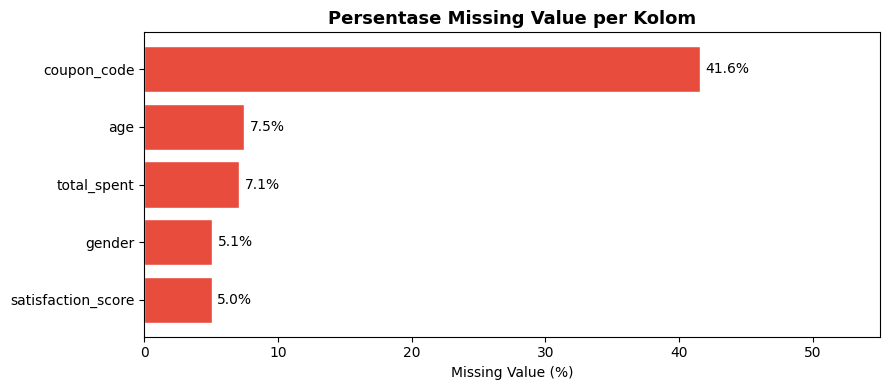

In [38]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df  = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(missing_df.index, missing_df['Missing %'], color='#e74c3c', edgecolor='white')
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in missing_df['Missing %']], padding=4, fontsize=10)
ax.set_xlabel('Missing Value (%)')
ax.set_title('Persentase Missing Value per Kolom', fontsize=13, fontweight='bold')
ax.set_xlim(0, 55)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 1.6 Distribusi Variabel Target (Churn)
> **Insight:** Dataset mengalami **class imbalance** — kelas churn (1) hanya sekitar 15.3%. Kondisi ini harus ditangani agar model tidak bias memprediksi kelas mayoritas. Pada tahap preprocessing akan digunakan **SMOTE** untuk menyeimbangkan kelas.

Distribusi Churn:
  Tidak Churn (0): 4,024 (85.2%)
  Churn (1): 699 (14.8%)


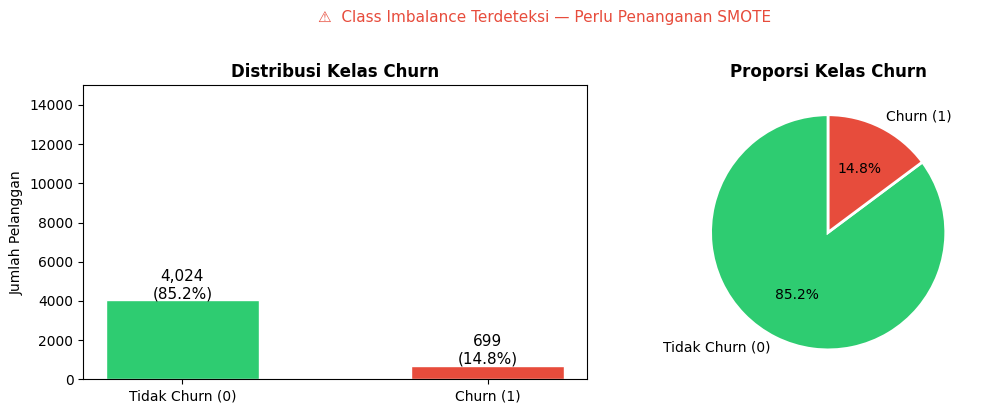

In [39]:
churn_counts = df['churn'].value_counts()
churn_pct    = df['churn'].value_counts(normalize=True) * 100

print('Distribusi Churn:')
for k, v in churn_counts.items():
    label = 'Churn' if k == 1 else 'Tidak Churn'
    print(f'  {label} ({k}): {v:,} ({churn_pct[k]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(['Tidak Churn (0)', 'Churn (1)'], churn_counts.values,
            color=colors, edgecolor='white', width=0.5)
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({churn_pct.values[i]:.1f}%)', ha='center', fontsize=11)
axes[0].set_title('Distribusi Kelas Churn', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].set_ylim(0, 15000)

axes[1].pie(churn_counts.values, labels=['Tidak Churn (0)', 'Churn (1)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas Churn', fontsize=12, fontweight='bold')

plt.suptitle('⚠️  Class Imbalance Terdeteksi — Perlu Penanganan SMOTE',
             fontsize=11, color='#e74c3c', y=1.02)
plt.tight_layout()
plt.show()

### 1.7 Heatmap Korelasi Fitur Numerik
> **Insight:** Korelasi dilihat untuk mengidentifikasi fitur yang berpotensi redundan atau sangat berpengaruh terhadap `churn`.

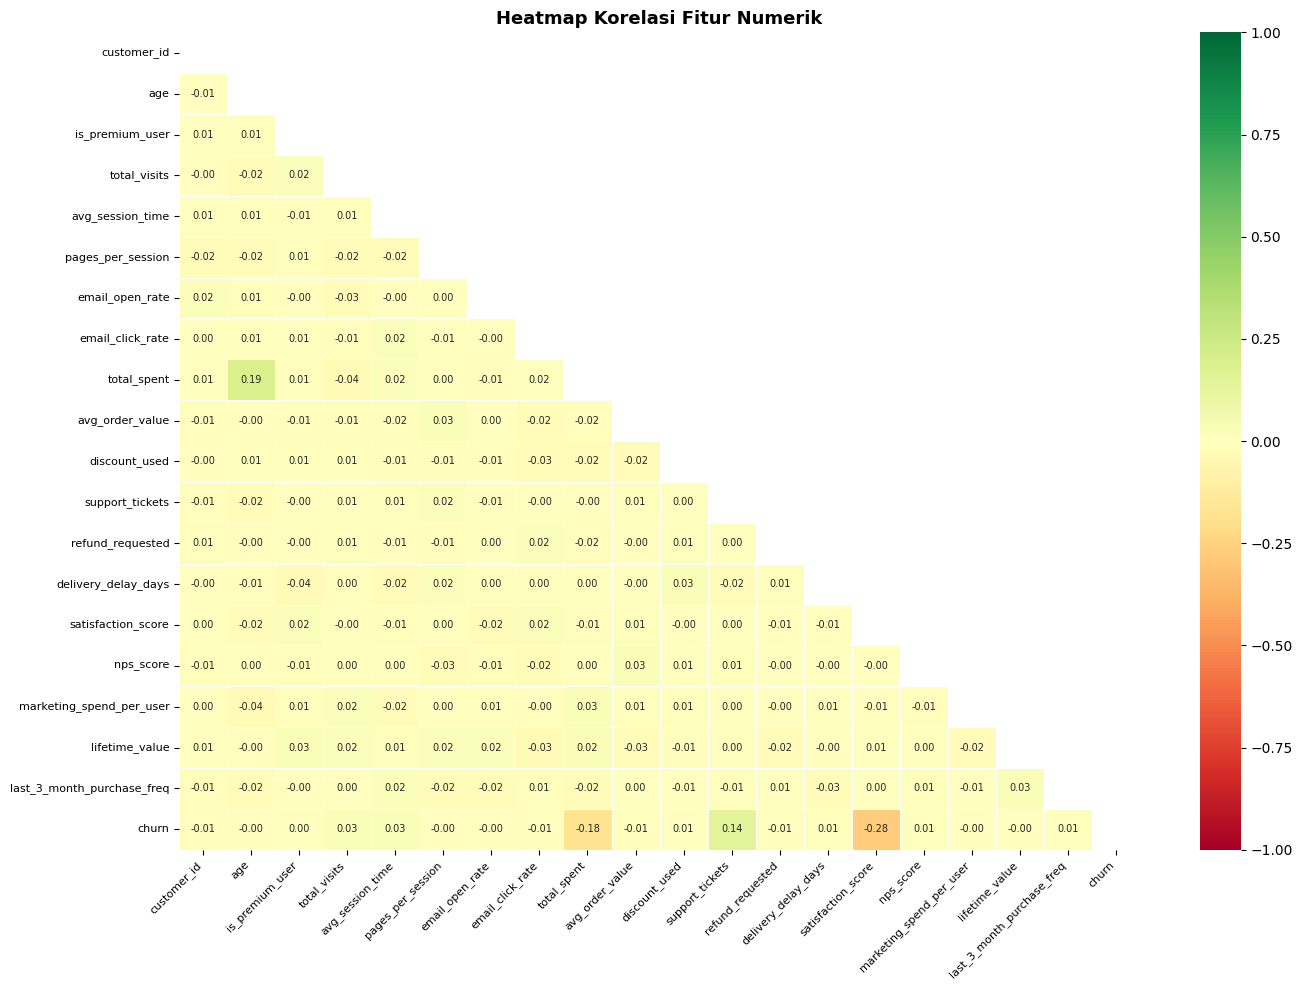


🎯 Korelasi terhadap variabel Churn (urut absolute):
satisfaction_score            0.281085
total_spent                   0.176554
support_tickets               0.144748
avg_session_time              0.030988
total_visits                  0.030679
avg_order_value               0.014618
email_click_rate              0.014306
nps_score                     0.012951
refund_requested              0.012778
last_3_month_purchase_freq    0.012547


In [40]:
num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.4, ax=ax, annot_kws={'size': 7}, vmin=-1, vmax=1, center=0)
ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

print('\n🎯 Korelasi terhadap variabel Churn (urut absolute):')
print(corr['churn'].drop('churn').abs().sort_values(ascending=False).head(10).to_string())

### 1.8 Distribusi Fitur Numerik Berdasarkan Status Churn

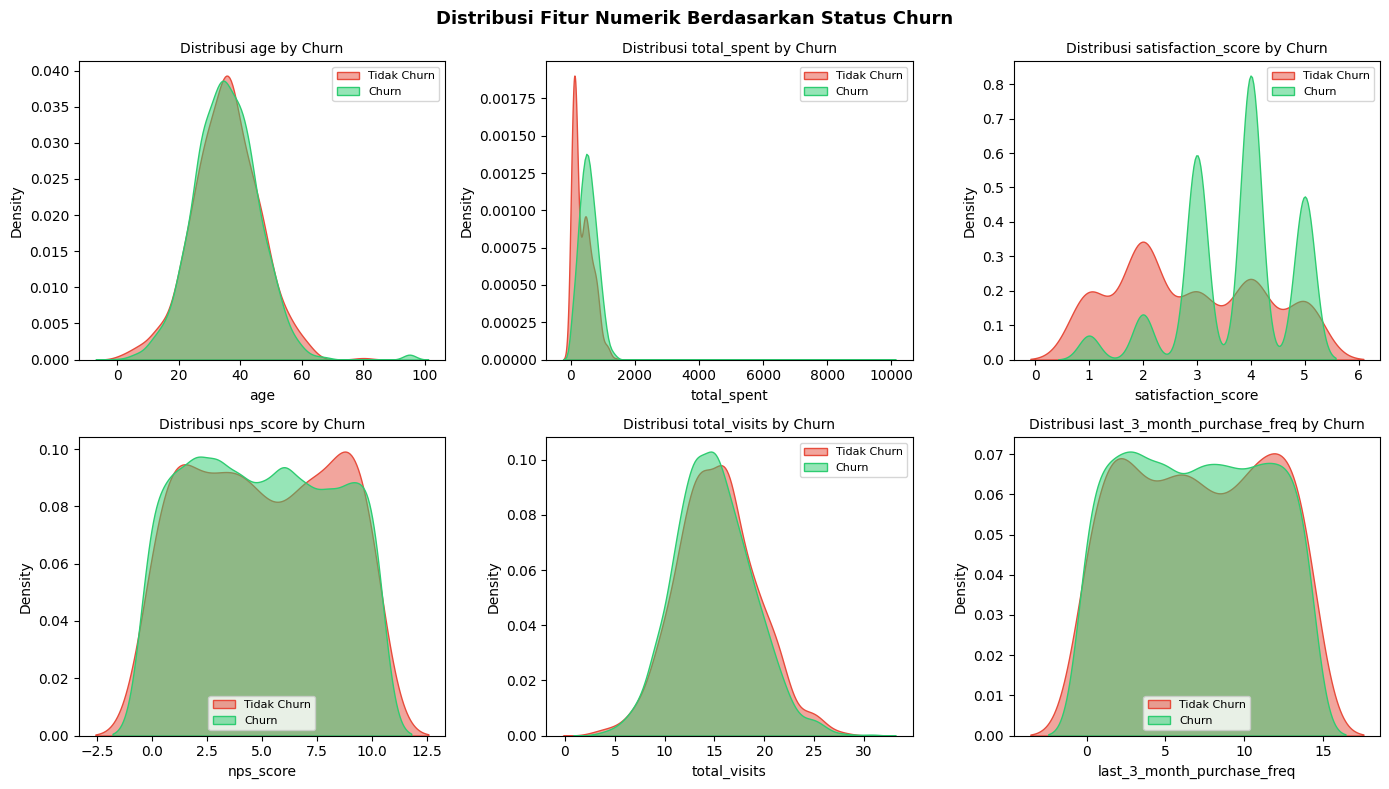

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
plot_cols = ['age', 'total_spent', 'satisfaction_score',
             'nps_score', 'total_visits', 'last_3_month_purchase_freq']
palette = {0: '#2ecc71', 1: '#e74c3c'}

for ax, col in zip(axes.flatten(), plot_cols):
    sns.kdeplot(data=df, x=col, hue='churn', fill=True,
                palette=palette, alpha=0.5, ax=ax, common_norm=False)
    ax.set_title(f'Distribusi {col} by Churn', fontsize=10)
    ax.legend(['Tidak Churn', 'Churn'], fontsize=8)

plt.suptitle('Distribusi Fitur Numerik Berdasarkan Status Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# BAGIAN 2 — DIRECT MODELING (Baseline)
> **Tujuan:** Melatih model tanpa preprocessing apapun untuk mendapatkan baseline performa. Hanya kolom numerik yang dipakai karena model tidak bisa menerima string mentah. Missing value diisi median secara minimal agar model bisa berjalan.

### 2.1 Persiapan Data — Direct

In [42]:
# Drop kolom non-numerik dan ID — tidak bisa digunakan langsung oleh model
drop_cols_direct = ['customer_id', 'gender', 'country', 'city', 'signup_date',
                    'last_purchase_date', 'acquisition_channel', 'device_type',
                    'subscription_type', 'coupon_code', 'payment_method']

df_direct = df.drop(columns=drop_cols_direct)

# Isi missing value numerik dengan median (minimal agar model bisa berjalan)
df_direct = df_direct.fillna(df_direct.median(numeric_only=True))

X_dir = df_direct.drop(columns=['churn'])
y_dir = df_direct['churn']

print(f'Fitur yang digunakan : {X_dir.shape[1]} kolom')
print(f'Kolom: {list(X_dir.columns)}')

Fitur yang digunakan : 18 kolom
Kolom: ['age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq']


### 2.2 Train-Test Split
> **Keputusan:** Proporsi **80:20** adalah standar industri. `stratify=y` digunakan agar distribusi kelas churn pada data latih dan uji tetap proporsional — penting karena data imbalanced. `random_state=42` untuk reproducibility.

In [43]:
RANDOM_STATE = 42
TEST_SIZE    = 0.2

X_train_dir, X_test_dir, y_train_dir, y_test_dir = train_test_split(
    X_dir, y_dir, test_size=TEST_SIZE,
    random_state=RANDOM_STATE, stratify=y_dir
)

print(f'Train : {X_train_dir.shape[0]:,} baris')
print(f'Test  : {X_test_dir.shape[0]:,} baris')
print(f'Proporsi Churn — Train: {y_train_dir.mean():.3f} | Test: {y_test_dir.mean():.3f}')

Train : 3,778 baris
Test  : 945 baris
Proporsi Churn — Train: 0.148 | Test: 0.148


### 2.3 Helper: Fungsi Evaluasi Model

In [44]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test, fit=True):
    if fit:
        model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)

    print(f'\n{"="*55}')
    print(f'  Model : {name}')
    print(f'{"="*55}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'\n  Classification Report:')
    print(classification_report(y_test, y_pred, target_names=['Tidak Churn', 'Churn']))

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: 0', 'Pred: 1'],
                yticklabels=['Actual: 0', 'Actual: 1'])
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {'model': name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'fitted_model': model}

print('✅ Fungsi evaluasi siap.')

✅ Fungsi evaluasi siap.


### 2.4 Latih & Evaluasi — Direct Modeling
> **Pilihan model:**
> - **Logistic Regression** (Konvensional) — Linear, interpretatif, cepat dilatih, cocok sebagai baseline
> - **Random Forest** (Ensemble Bagging) — Robust terhadap overfitting, menggabungkan banyak Decision Tree secara paralel
> - **Voting Classifier** (Ensemble Voting) — Menggabungkan prediksi LR + KNN + RF dengan voting mayoritas


  Model : Logistic Regression [Direct]
  Accuracy  : 0.8434
  Precision : 0.4091
  Recall    : 0.1286
  F1-Score  : 0.1957

  Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.86      0.97      0.91       805
       Churn       0.41      0.13      0.20       140

    accuracy                           0.84       945
   macro avg       0.64      0.55      0.55       945
weighted avg       0.80      0.84      0.81       945



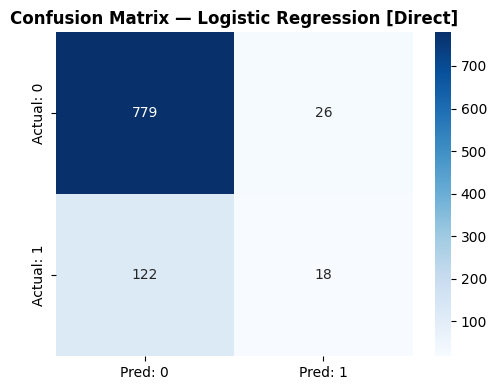

In [45]:
# Model 1: Logistic Regression
lr_dir = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
res_lr_dir = evaluate_model('Logistic Regression [Direct]',
                             lr_dir, X_train_dir, X_test_dir, y_train_dir, y_test_dir)


  Model : Random Forest [Direct]
  Accuracy  : 0.8413
  Precision : 0.4468
  Recall    : 0.3000
  F1-Score  : 0.3590

  Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.88      0.94      0.91       805
       Churn       0.45      0.30      0.36       140

    accuracy                           0.84       945
   macro avg       0.67      0.62      0.63       945
weighted avg       0.82      0.84      0.83       945



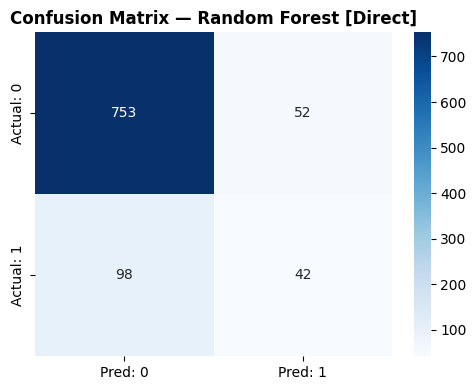

In [46]:
# Model 2: Random Forest
rf_dir = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
res_rf_dir = evaluate_model('Random Forest [Direct]',
                             rf_dir, X_train_dir, X_test_dir, y_train_dir, y_test_dir)


  Model : Voting Classifier (LR+KNN+RF) [Direct]
  Accuracy  : 0.8392
  Precision : 0.3800
  Recall    : 0.1357
  F1-Score  : 0.2000

  Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.86      0.96      0.91       805
       Churn       0.38      0.14      0.20       140

    accuracy                           0.84       945
   macro avg       0.62      0.55      0.56       945
weighted avg       0.79      0.84      0.81       945



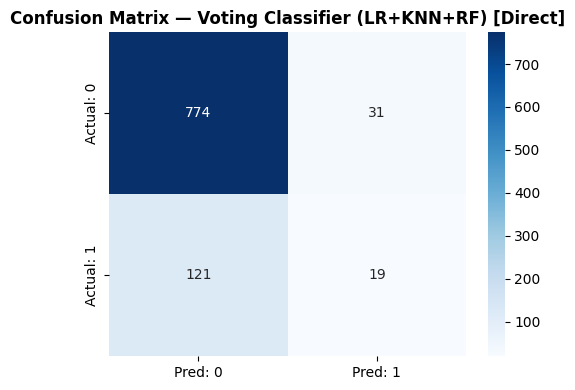

In [47]:
# Model 3: Voting Classifier (LR + KNN + RF)
estimators_dir = [
    ('lr',  LogisticRegression(random_state=RANDOM_STATE, max_iter=500)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('rf2', RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1))
]
vc_dir = VotingClassifier(estimators=estimators_dir, voting='hard', n_jobs=-1)
res_vc_dir = evaluate_model('Voting Classifier (LR+KNN+RF) [Direct]',
                             vc_dir, X_train_dir, X_test_dir, y_train_dir, y_test_dir)

### 2.5 Ringkasan Performa — Direct Modeling

In [48]:
results_direct = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'fitted_model'}
    for r in [res_lr_dir, res_rf_dir, res_vc_dir]
])
print('\n📊 Ringkasan Performa — Direct Modeling')
print(results_direct.set_index('model').round(4).to_string())


📊 Ringkasan Performa — Direct Modeling
                                        accuracy  precision  recall      f1
model                                                                      
Logistic Regression [Direct]              0.8434     0.4091  0.1286  0.1957
Random Forest [Direct]                    0.8413     0.4468  0.3000  0.3590
Voting Classifier (LR+KNN+RF) [Direct]    0.8392     0.3800  0.1357  0.2000


---
# BAGIAN 3 — MODELING DENGAN PREPROCESSING
> **Tujuan:** Membersihkan data, encoding fitur kategorikal, menangani imbalance dengan SMOTE, lalu melatih ulang ketiga model.

### 3.1 Step 1 — Drop Kolom ID & Datetime

In [49]:
df_prep = df.copy()

# customer_id  : ID unik, tidak prediktif
# signup_date & last_purchase_date : tipe string datetime, butuh feature engineering
#   khusus yang di luar scope tugas ini, maka di-drop
df_prep.drop(columns=['customer_id', 'signup_date', 'last_purchase_date'], inplace=True)
print(f'Shape setelah drop ID & datetime: {df_prep.shape}')

Shape setelah drop ID & datetime: (4723, 27)


### 3.2 Step 2 — Handle Missing Value

In [50]:
# coupon_code (41% missing) → ubah jadi fitur biner has_coupon
# Alasan: info PUNYA/TIDAK kupon lebih bermakna dari kode kuponnya sendiri
df_prep['has_coupon'] = df_prep['coupon_code'].notna().astype(int)
df_prep.drop(columns=['coupon_code'], inplace=True)

# Numerik → imputasi median (robust terhadap outlier)
df_prep['age']                = df_prep['age'].fillna(df_prep['age'].median())
df_prep['total_spent']        = df_prep['total_spent'].fillna(df_prep['total_spent'].median())
df_prep['satisfaction_score'] = df_prep['satisfaction_score'].fillna(df_prep['satisfaction_score'].median())

# Kategorik → imputasi modus
df_prep['gender'] = df_prep['gender'].fillna(df_prep['gender'].mode()[0])

print(f'Missing value tersisa: {df_prep.isnull().sum().sum()}')

Missing value tersisa: 0


### 3.3 Step 3 — Handle Duplikasi

In [51]:
n_dup = df_prep.duplicated().sum()
df_prep.drop_duplicates(inplace=True)
print(f'Baris duplikat dihapus: {n_dup}')
print(f'Shape setelah de-duplikasi: {df_prep.shape}')

Baris duplikat dihapus: 0
Shape setelah de-duplikasi: (4723, 27)


### 3.4 Step 4 — Handle Outlier (IQR Capping)
> **Keputusan:** Gunakan capping (winsorizing) bukan deletion. Outlier pada data pelanggan (misal `total_spent` sangat tinggi) bisa jadi pelanggan VIP yang valid. Menghapus mereka justru menghilangkan informasi berharga. Capping menjaga nilai di batas wajar tanpa membuang data.

In [52]:
# Kolom yang di-cap: fitur numerik kontinyu saja
# Kolom biner (0/1) tidak perlu di-cap
binary_cols  = ['churn', 'is_premium_user', 'discount_used', 'refund_requested', 'has_coupon']
cap_cols     = df_prep.select_dtypes(include='number').columns.difference(binary_cols).tolist()

# Simpan data sebelum capping untuk visualisasi
df_before_cap = df_prep[cap_cols].copy()

n_outlier_total = 0
for col in cap_cols:
    Q1, Q3 = df_prep[col].quantile([0.25, 0.75])
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    n_out  = ((df_prep[col] < lower) | (df_prep[col] > upper)).sum()
    n_outlier_total += n_out
    df_prep[col] = df_prep[col].clip(lower=lower, upper=upper)

print(f'Total nilai di-cap (outlier): {n_outlier_total:,}')

Total nilai di-cap (outlier): 605


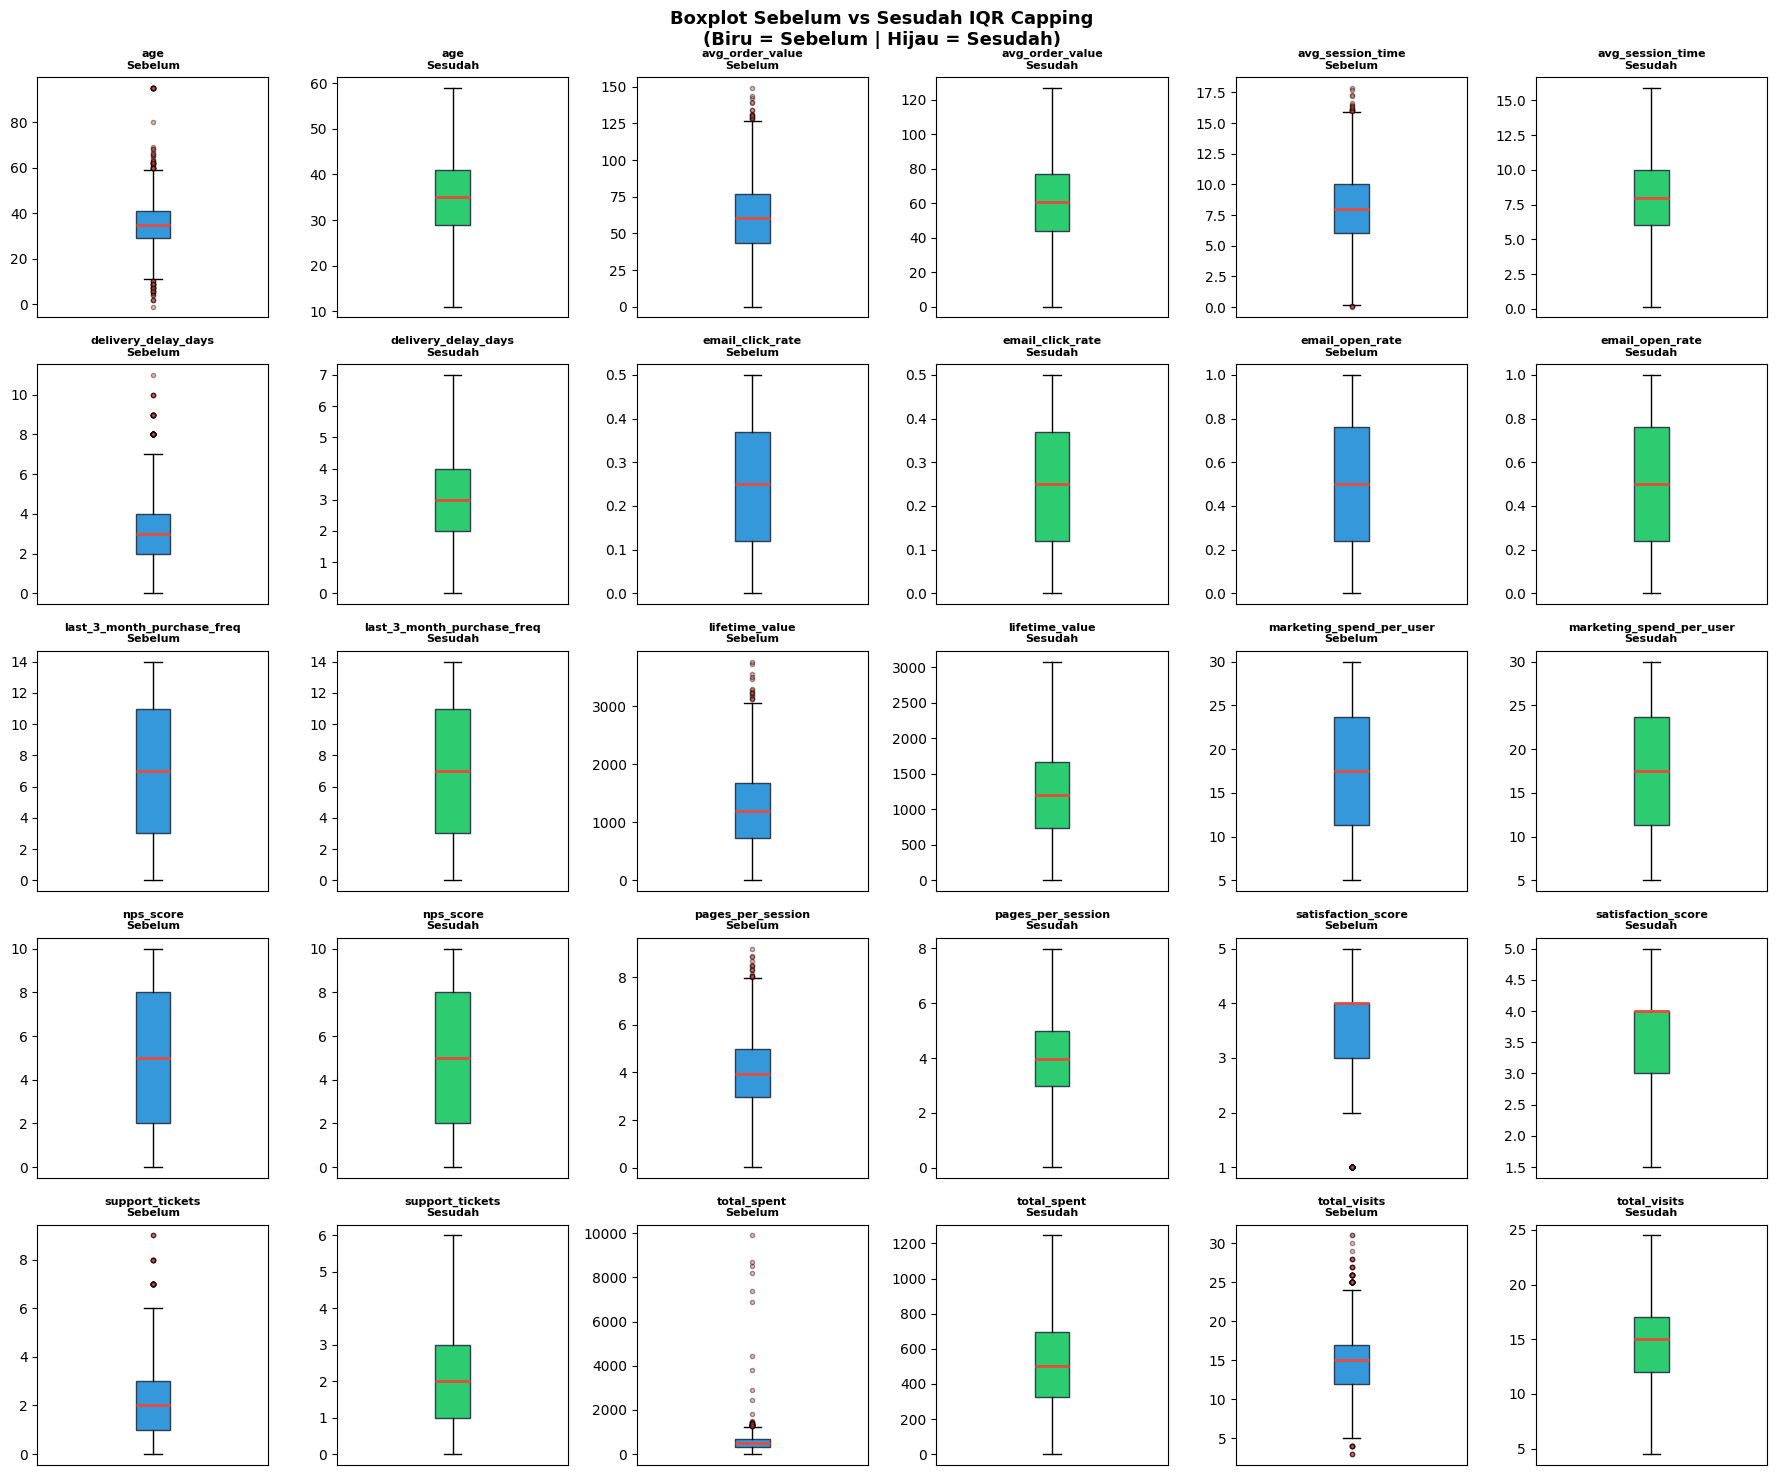

In [53]:
# Visualisasi Outlier — Sebelum vs Sesudah Capping
n_cols = 3
n_rows = (len(cap_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols * 2, figsize=(18, n_rows * 3))

for i, col in enumerate(cap_cols):
    ax_before = axes[i // n_cols][( i % n_cols) * 2]
    ax_after  = axes[i // n_cols][(i % n_cols) * 2 + 1]

    ax_before.boxplot(df_before_cap[col], patch_artist=True,
                      boxprops=dict(facecolor='#3498db', color='#2c3e50'),
                      medianprops=dict(color='#e74c3c', linewidth=2),
                      flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=3, alpha=0.4))
    ax_before.set_title(f'{col}\nSebelum', fontsize=8, fontweight='bold')
    ax_before.set_xticks([])

    ax_after.boxplot(df_prep[col], patch_artist=True,
                     boxprops=dict(facecolor='#2ecc71', color='#2c3e50'),
                     medianprops=dict(color='#e74c3c', linewidth=2),
                     flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=3, alpha=0.4))
    ax_after.set_title(f'{col}\nSesudah', fontsize=8, fontweight='bold')
    ax_after.set_xticks([])

# Sembunyikan subplot kosong
total_subplots = n_rows * n_cols * 2
for j in range(len(cap_cols) * 2, total_subplots):
    fig.axes[j].set_visible(False)

plt.suptitle('Boxplot Sebelum vs Sesudah IQR Capping\n(Biru = Sebelum | Hijau = Sesudah)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Step 5 — Encoding Fitur Kategorikal
> **Keputusan:**
> - `subscription_type` (2 nilai: Annual/Monthly) → **LabelEncoder**, cukup jadi 0 dan 1
> - `gender` (3 nilai: Male/Female/Other) → **One-Hot Encoding**, agar model tidak mengasumsikan urutan ordinal
> - `country`, `acquisition_channel`, `device_type`, `payment_method` → **One-Hot Encoding**
> - `city` (kardinalitas tinggi) → **di-drop** untuk menghindari curse of dimensionality

In [54]:
# Label encode subscription_type (2 nilai)
le = LabelEncoder()
df_prep['subscription_type'] = le.fit_transform(df_prep['subscription_type'])
print(f'subscription_type mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# One-Hot Encoding untuk kolom nominal
ohe_cols = ['gender', 'country', 'acquisition_channel', 'device_type', 'payment_method']
df_prep  = pd.get_dummies(df_prep, columns=ohe_cols, drop_first=True)

# Drop city
df_prep.drop(columns=['city'], inplace=True)

# Konversi kolom boolean hasil OHE ke int
bool_cols = df_prep.select_dtypes(include='bool').columns
df_prep[bool_cols] = df_prep[bool_cols].astype(int)

print(f'Shape setelah encoding: {df_prep.shape}')
print('✅ Preprocessing selesai.')

subscription_type mapping: {'Annual': np.int64(0), 'Monthly': np.int64(1)}
Shape setelah encoding: (4723, 37)
✅ Preprocessing selesai.


### 3.6 Train-Test Split (Proporsi Sama 80:20)

In [55]:
X_prep = df_prep.drop(columns=['churn'])
y_prep = df_prep['churn']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_prep, y_prep, test_size=TEST_SIZE,
    random_state=RANDOM_STATE, stratify=y_prep
)
print(f'Train: {X_train_p.shape} | Test: {X_test_p.shape}')

Train: (3778, 36) | Test: (945, 36)


### 3.7 Scaling (Setelah Split)
> **Keputusan:** Scaling dilakukan **setelah** split untuk menghindari **data leakage** — jika sebelum split, statistik dari data test akan mempengaruhi scaler sehingga evaluasi menjadi terlalu optimistis. `StandardScaler` dipilih karena data sudah di-cap dari outlier.

In [56]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_p)   # fit HANYA pada train
X_test_sc  = scaler.transform(X_test_p)         # transform test pakai statistik train
print('✅ Scaling selesai (fit pada train, transform pada test).')

✅ Scaling selesai (fit pada train, transform pada test).


### 3.8 Tangani Class Imbalance — SMOTE
> **Keputusan:** SMOTE diterapkan **hanya pada data train**, bukan test. Data test harus mencerminkan distribusi dunia nyata. SMOTE menghasilkan sampel sintetis dari kelas minoritas berdasarkan KNN, lebih baik dari random oversampling biasa.

In [57]:
print(f'Sebelum SMOTE — Churn=0: {(y_train_p==0).sum():,} | Churn=1: {(y_train_p==1).sum():,}')

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train_p)

print(f'Setelah SMOTE  — Churn=0: {(y_train_sm==0).sum():,} | Churn=1: {(y_train_sm==1).sum():,}')
print(f'Total data train setelah SMOTE: {len(y_train_sm):,}')

Sebelum SMOTE — Churn=0: 3,219 | Churn=1: 559
Setelah SMOTE  — Churn=0: 3,219 | Churn=1: 3,219
Total data train setelah SMOTE: 6,438


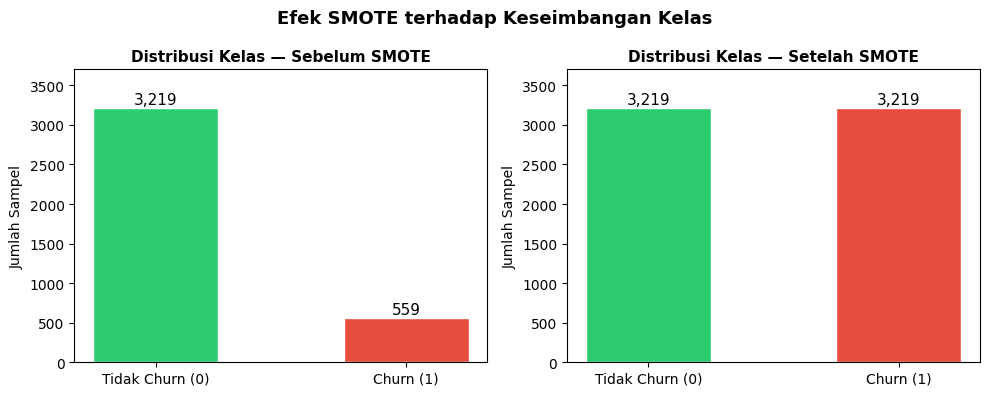

In [58]:
# Visualisasi Efek SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#2ecc71', '#e74c3c']

before = pd.Series(y_train_p).value_counts().sort_index()
axes[0].bar(['Tidak Churn (0)', 'Churn (1)'], before.values,
            color=colors, edgecolor='white', width=0.5)
for i, v in enumerate(before.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=11)
axes[0].set_title('Distribusi Kelas — Sebelum SMOTE', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_ylim(0, before.max() * 1.15)

after = pd.Series(y_train_sm).value_counts().sort_index()
axes[1].bar(['Tidak Churn (0)', 'Churn (1)'], after.values,
            color=colors, edgecolor='white', width=0.5)
for i, v in enumerate(after.values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontsize=11)
axes[1].set_title('Distribusi Kelas — Setelah SMOTE', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_ylim(0, after.max() * 1.15)

plt.suptitle('Efek SMOTE terhadap Keseimbangan Kelas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.9 Latih & Evaluasi — Dengan Preprocessing


  Model : Logistic Regression [Preprocessing]
  Accuracy  : 0.7228
  Precision : 0.3094
  Recall    : 0.7071
  F1-Score  : 0.4304

  Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.93      0.73      0.82       805
       Churn       0.31      0.71      0.43       140

    accuracy                           0.72       945
   macro avg       0.62      0.72      0.62       945
weighted avg       0.84      0.72      0.76       945



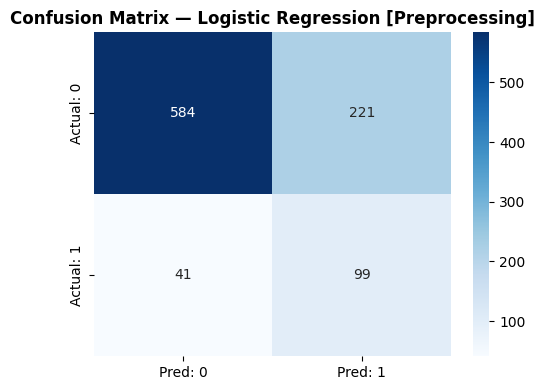

In [59]:
# Model 1: Logistic Regression
lr_prep = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
res_lr_prep = evaluate_model('Logistic Regression [Preprocessing]',
                              lr_prep, X_train_sm, X_test_sc, y_train_sm, y_test_p)


  Model : Random Forest [Preprocessing]
  Accuracy  : 0.8360
  Precision : 0.4490
  Recall    : 0.4714
  F1-Score  : 0.4599

  Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.91      0.90      0.90       805
       Churn       0.45      0.47      0.46       140

    accuracy                           0.84       945
   macro avg       0.68      0.69      0.68       945
weighted avg       0.84      0.84      0.84       945



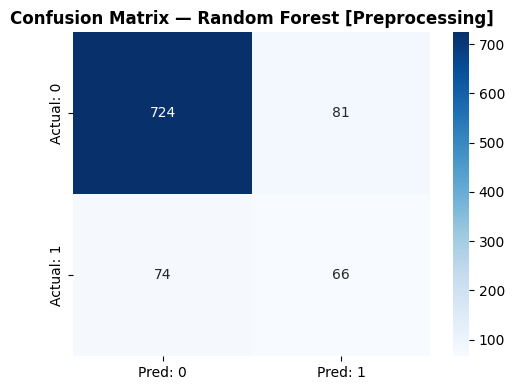

In [60]:
# Model 2: Random Forest
rf_prep = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
res_rf_prep = evaluate_model('Random Forest [Preprocessing]',
                              rf_prep, X_train_sm, X_test_sc, y_train_sm, y_test_p)


  Model : Voting Classifier (LR+SVM+KNN) [Preprocessing]
  Accuracy  : 0.8042
  Precision : 0.3923
  Recall    : 0.5857
  F1-Score  : 0.4699

  Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.92      0.84      0.88       805
       Churn       0.39      0.59      0.47       140

    accuracy                           0.80       945
   macro avg       0.66      0.71      0.67       945
weighted avg       0.84      0.80      0.82       945



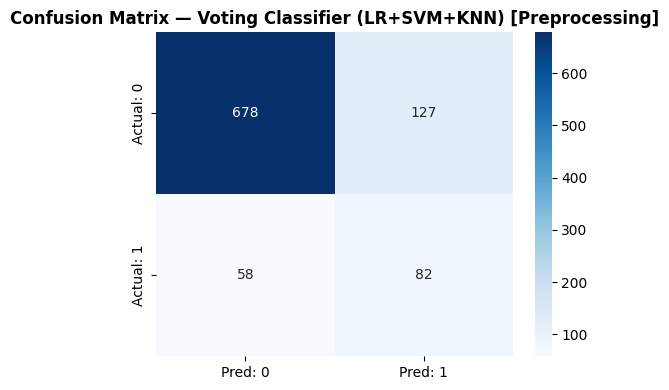

In [61]:
# Model 3: Voting Classifier (LR + SVM + KNN)
# Setelah scaling & SMOTE, SVM dan KNN bekerja optimal
estimators_prep = [
    ('lr',  LogisticRegression(random_state=RANDOM_STATE, max_iter=500)),
    ('svm', SVC(probability=True, random_state=RANDOM_STATE)),
    ('knn', KNeighborsClassifier(n_neighbors=7))
]
vc_prep = VotingClassifier(estimators=estimators_prep, voting='soft', n_jobs=-1)
res_vc_prep = evaluate_model('Voting Classifier (LR+SVM+KNN) [Preprocessing]',
                              vc_prep, X_train_sm, X_test_sc, y_train_sm, y_test_p)

### 3.10 Ringkasan Performa — Preprocessing

In [62]:
results_prep = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'fitted_model'}
    for r in [res_lr_prep, res_rf_prep, res_vc_prep]
])
print('\n📊 Ringkasan Performa — Preprocessing')
print(results_prep.set_index('model').round(4).to_string())


📊 Ringkasan Performa — Preprocessing
                                                accuracy  precision  recall      f1
model                                                                              
Logistic Regression [Preprocessing]               0.7228     0.3094  0.7071  0.4304
Random Forest [Preprocessing]                     0.8360     0.4490  0.4714  0.4599
Voting Classifier (LR+SVM+KNN) [Preprocessing]    0.8042     0.3923  0.5857  0.4699


---
# BAGIAN 4 — HYPERPARAMETER TUNING + FEATURE SELECTION
> **Tujuan:** Mengoptimalkan model terbaik dari skenario preprocessing menggunakan feature selection berbasis importance dan RandomizedSearchCV.

### 4.1 Feature Importance Analysis
> **Keputusan:** Random Forest digunakan sebagai estimator feature importance karena secara native menghasilkan skor berbasis Gini impurity. Fitur dengan importance sangat rendah (< 0.005) akan dieliminasi untuk mengurangi noise.

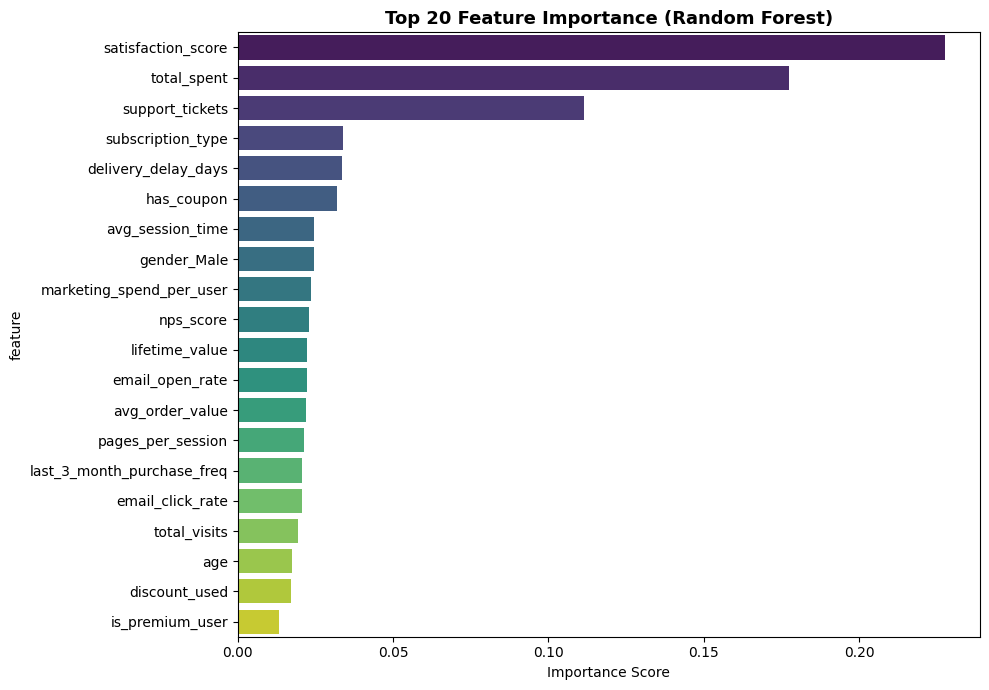

                   feature  importance
        satisfaction_score    0.227558
               total_spent    0.177312
           support_tickets    0.111386
         subscription_type    0.034004
       delivery_delay_days    0.033572
                has_coupon    0.031837
          avg_session_time    0.024527
               gender_Male    0.024481
  marketing_spend_per_user    0.023521
                 nps_score    0.022819
            lifetime_value    0.022327
           email_open_rate    0.022250
           avg_order_value    0.022025
         pages_per_session    0.021220
last_3_month_purchase_freq    0.020683
          email_click_rate    0.020638
              total_visits    0.019315
                       age    0.017346
             discount_used    0.017116
           is_premium_user    0.013352


In [63]:
feature_names = X_prep.columns.tolist()
importances   = res_rf_prep['fitted_model'].feature_importances_

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).reset_index(drop=True)

# Visualisasi Top 20
top_n = 20
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=fi_df.head(top_n), x='importance', y='feature', palette='viridis', ax=ax)
ax.set_title(f'Top {top_n} Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(fi_df.head(top_n).to_string(index=False))

### 4.2 Seleksi Fitur Berdasarkan Importance

In [64]:
IMPORTANCE_THRESHOLD = 0.005
selected_features = fi_df[fi_df['importance'] >= IMPORTANCE_THRESHOLD]['feature'].tolist()

print(f'Fitur terpilih : {len(selected_features)} dari {len(feature_names)}')
print(f'Fitur dibuang  : {len(feature_names) - len(selected_features)}')

# Re-scale pada fitur terpilih saja (fit pada train, transform pada test)
X_train_sel = X_train_p[selected_features]
X_test_sel  = X_test_p[selected_features]

scaler_sel     = StandardScaler()
X_train_sel_sc = scaler_sel.fit_transform(X_train_sel)
X_test_sel_sc  = scaler_sel.transform(X_test_sel)

# SMOTE pada fitur terpilih
X_train_sel_sm, y_train_sel_sm = smote.fit_resample(X_train_sel_sc, y_train_p)
print(f'\nShape train setelah feature selection + SMOTE: {X_train_sel_sm.shape}')

Fitur terpilih : 28 dari 36
Fitur dibuang  : 8

Shape train setelah feature selection + SMOTE: (6438, 28)


### 4.3 Hyperparameter Tuning — Logistic Regression
> **Keputusan:** `RandomizedSearchCV` dipilih dibanding `GridSearchCV` karena lebih efisien pada ruang hyperparameter besar. `StratifiedKFold` (cv=5) menjaga proporsi kelas di setiap fold. Scoring menggunakan **F1** karena lebih seimbang antara precision dan recall — pada kasus churn, False Negative (gagal prediksi churn) lebih mahal dari False Positive.

In [65]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_param_grid = {
    'C'       : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty' : ['l1', 'l2'],
    'solver'  : ['liblinear', 'saga'],
    'max_iter': [200, 500, 1000]
}

lr_search = RandomizedSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    param_distributions=lr_param_grid,
    n_iter=30, scoring='f1', cv=cv_strategy,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
lr_search.fit(X_train_sel_sm, y_train_sel_sm)

print(f'\n✅ Best Params LR : {lr_search.best_params_}')
print(f'   Best F1 (CV)   : {lr_search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best Params LR : {'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 1000, 'C': 0.001}
   Best F1 (CV)   : 0.7929



  Model : Logistic Regression [Tuned]
  Accuracy  : 0.6624
  Precision : 0.2746
  Recall    : 0.7786
  F1-Score  : 0.4060

  Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.94      0.64      0.76       805
       Churn       0.27      0.78      0.41       140

    accuracy                           0.66       945
   macro avg       0.61      0.71      0.59       945
weighted avg       0.84      0.66      0.71       945



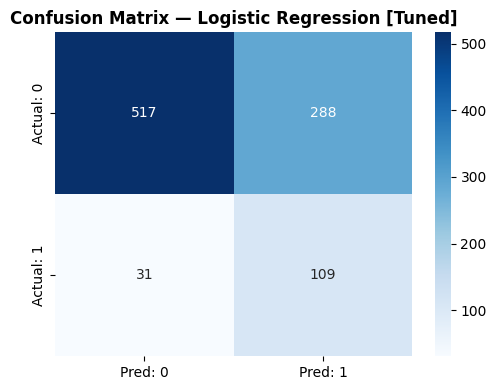

In [66]:
res_lr_tuned = evaluate_model('Logistic Regression [Tuned]',
                               lr_search.best_estimator_,
                               X_train_sel_sm, X_test_sel_sc,
                               y_train_sel_sm, y_test_p, fit=False)

### 4.4 Hyperparameter Tuning — Random Forest

In [83]:
rf_param_grid = {
    'n_estimators'      : [50, 100, 150],       # turunkan upper bound dari 500 -> 150
    'max_depth'         : [10, 15, 20],         # hapus None, biar tree tidak tumbuh tanpa batas
    'min_samples_split' : [5, 10, 15],          # naikkan minimum, kurangi node berlebih
    'min_samples_leaf'  : [2, 3, 5],            # naikkan minimum dari 1, daun tidak terlalu rapat
    'max_features'      : ['sqrt', 'log2'],
    'class_weight'      : [None, 'balanced']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=10, scoring='f1', cv=cv_strategy,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
rf_search.fit(X_train_sel_sm, y_train_sel_sm)

print(f'\n✅ Best Params RF : {rf_search.best_params_}')
print(f'   Best F1 (CV)   : {rf_search.best_score_:.4f}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits

✅ Best Params RF : {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20, 'class_weight': None}
   Best F1 (CV)   : 0.9302



  Model : Random Forest [Tuned]
  Accuracy  : 0.8413
  Precision : 0.4702
  Recall    : 0.5643
  F1-Score  : 0.5130

  Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.92      0.89      0.91       805
       Churn       0.47      0.56      0.51       140

    accuracy                           0.84       945
   macro avg       0.70      0.73      0.71       945
weighted avg       0.85      0.84      0.85       945



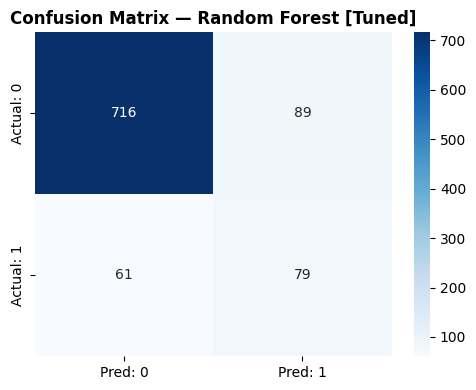

In [84]:
res_rf_tuned = evaluate_model('Random Forest [Tuned]',
                               rf_search.best_estimator_,
                               X_train_sel_sm, X_test_sel_sc,
                               y_train_sel_sm, y_test_p, fit=False)

### 4.5 Hyperparameter Tuning — Voting Classifier
> **Keputusan:** Pada VotingClassifier, tuning dilakukan pada komponen internal menggunakan format `estimator__param` agar setiap sub-model bisa dioptimalkan sekaligus dalam satu pencarian.

In [79]:
from sklearn.svm import LinearSVC

vc_base = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(random_state=RANDOM_STATE, max_iter=500)),
        # ('svm', SVC(probability=True, random_state=RANDOM_STATE)),
        ('svm', LinearSVC(random_state=RANDOM_STATE, max_iter=2000)),
        ('knn', KNeighborsClassifier())
    ],
    voting='hard'
)

vc_param_grid = {
    'lr__C'           : [0.1, 1, 10],
    'svm__C'          : [0.1, 1, 10],
    # 'svm__kernel'     : ['rbf', 'linear'], # LinearSVC does not have a 'kernel' parameter
    'knn__n_neighbors': [5, 7, 11]
}

vc_search = RandomizedSearchCV(
    vc_base,
    param_distributions=vc_param_grid,
    n_iter=15, scoring='f1', cv=cv_strategy,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
vc_search.fit(X_train_sel_sm, y_train_sel_sm)

print(f'\n✅ Best Params VC : {vc_search.best_params_}')
print(f'   Best F1 (CV)   : {vc_search.best_score_:.4f}')

Fitting 5 folds for each of 15 candidates, totalling 75 fits

✅ Best Params VC : {'svm__C': 10, 'lr__C': 10, 'knn__n_neighbors': 5}
   Best F1 (CV)   : 0.7843



  Model : Voting Classifier [Tuned]
  Accuracy  : 0.7101
  Precision : 0.3018
  Recall    : 0.7286
  F1-Score  : 0.4268

  Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.94      0.71      0.81       805
       Churn       0.30      0.73      0.43       140

    accuracy                           0.71       945
   macro avg       0.62      0.72      0.62       945
weighted avg       0.84      0.71      0.75       945



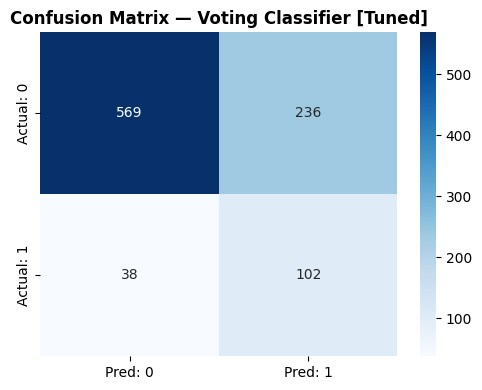

In [80]:
res_vc_tuned = evaluate_model('Voting Classifier [Tuned]',
                               vc_search.best_estimator_,
                               X_train_sel_sm, X_test_sel_sc,
                               y_train_sel_sm, y_test_p, fit=False)

### 4.6 Perbandingan Semua 9 Model


📊 RINGKASAN SEMUA 9 MODEL
                                         model  accuracy  precision  recall     f1
                  Logistic Regression [Direct]    0.8434     0.4091  0.1286 0.1957
                        Random Forest [Direct]    0.8413     0.4468  0.3000 0.3590
        Voting Classifier (LR+KNN+RF) [Direct]    0.8392     0.3800  0.1357 0.2000
           Logistic Regression [Preprocessing]    0.7228     0.3094  0.7071 0.4304
                 Random Forest [Preprocessing]    0.8360     0.4490  0.4714 0.4599
Voting Classifier (LR+SVM+KNN) [Preprocessing]    0.8042     0.3923  0.5857 0.4699
                   Logistic Regression [Tuned]    0.6624     0.2746  0.7786 0.4060
                         Random Forest [Tuned]    0.8413     0.4702  0.5643 0.5130
                     Voting Classifier [Tuned]    0.7101     0.3018  0.7286 0.4268


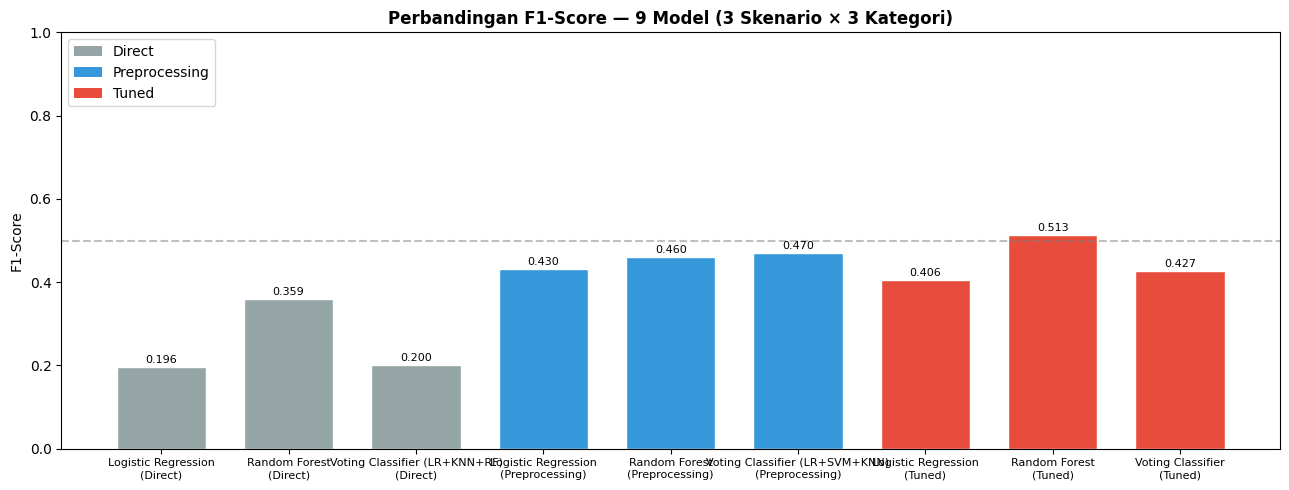

In [85]:
all_results = [res_lr_dir, res_rf_dir, res_vc_dir,
               res_lr_prep, res_rf_prep, res_vc_prep,
               res_lr_tuned, res_rf_tuned, res_vc_tuned]

df_results = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'fitted_model'}
    for r in all_results
])
df_results['skenario']   = ['Direct']*3 + ['Preprocessing']*3 + ['Tuned']*3
df_results['model_type'] = ['LR', 'RF', 'VC'] * 3

print('\n📊 RINGKASAN SEMUA 9 MODEL')
print(df_results[['model','accuracy','precision','recall','f1']].round(4).to_string(index=False))

# Visualisasi
colors_skenario = {'Direct': '#95a5a6', 'Preprocessing': '#3498db', 'Tuned': '#e74c3c'}
fig, ax = plt.subplots(figsize=(13, 5))
for i, row in df_results.iterrows():
    ax.bar(i, row['f1'], color=colors_skenario[row['skenario']], edgecolor='white', width=0.7)
    ax.text(i, row['f1'] + 0.005, f"{row['f1']:.3f}", ha='center', va='bottom', fontsize=8)

labels = [r['model'].replace(' [Direct]','').replace(' [Preprocessing]','').replace(' [Tuned]','')
          + f"\n({df_results.iloc[i]['skenario']})" for i, r in enumerate(all_results)]
ax.set_xticks(range(9))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('F1-Score')
ax.set_title('Perbandingan F1-Score — 9 Model (3 Skenario × 3 Kategori)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in colors_skenario.items()]
ax.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.show()

### 4.7 Identifikasi & Simpan Model Terbaik

In [86]:
best_idx       = df_results['f1'].idxmax()
best_row       = df_results.loc[best_idx]
best_fitted    = all_results[best_idx]['fitted_model']

print('🏆 MODEL TERBAIK:')
print(f'   Nama      : {best_row["model"]}')
print(f'   Skenario  : {best_row["skenario"]}')
print(f'   Accuracy  : {best_row["accuracy"]:.4f}')
print(f'   Precision : {best_row["precision"]:.4f}')
print(f'   Recall    : {best_row["recall"]:.4f}')
print(f'   F1-Score  : {best_row["f1"]:.4f}')

# Simpan model, scaler, dan daftar fitur terpilih
joblib.dump(best_fitted,       'best_model.pkl')
joblib.dump(scaler_sel,        'scaler.pkl')
joblib.dump(selected_features, 'selected_features.pkl')

print('\n✅ File tersimpan:')
print('   - best_model.pkl')
print('   - scaler.pkl')
print('   - selected_features.pkl')

🏆 MODEL TERBAIK:
   Nama      : Random Forest [Tuned]
   Skenario  : Tuned
   Accuracy  : 0.8413
   Precision : 0.4702
   Recall    : 0.5643
   F1-Score  : 0.5130

✅ File tersimpan:
   - best_model.pkl
   - scaler.pkl
   - selected_features.pkl


---
## ✅ Summary Keputusan

| Aspek | Keputusan | Alasan |
|---|---|---|
| Train-Test Split | 80:20, stratified | Proporsi standar; stratify jaga distribusi kelas |
| Missing Value | Median/mode + `has_coupon` biner | Robust outlier; kupon lebih informatif sebagai biner |
| Outlier | IQR Capping | Preservasi data pelanggan VIP |
| Encoding | LabelEncoder (2 nilai) + OHE (>2 nilai) | Hindari ordinal bias pada gender & nominal lain |
| Drop Fitur | `city` (kardinalitas tinggi), ID, datetime | Curse of dimensionality |
| Scaling | StandardScaler setelah split | Cegah data leakage |
| Imbalance | SMOTE hanya pada train | Test tetap mencerminkan distribusi nyata |
| Feature Selection | Importance ≥ 0.005 | Kurangi noise tanpa buang sinyal penting |
| Tuning | RandomizedSearchCV + StratifiedKFold(5) | Efisien; CV terjaga proporsi kelas |
| Scoring | F1-Score | FN lebih mahal di kasus churn |

---
*Next step → Deployment ke Streamlit Cloud*

---
# BAGIAN 5 — DEPLOYMENT KE STREAMLIT (via Google Colab)
> **Tujuan:** Menyimpan ulang model, scaler, dan fitur terpilih sebagai artifact siap pakai, membangun aplikasi Streamlit untuk prediksi churn, lalu menjalankannya langsung dari Colab menggunakan tunnel publik.

**Catatan penting:** Colab tidak memiliki server publik. Agar aplikasi Streamlit (yang berjalan di `localhost:8501` dalam VM Colab) bisa diakses dari browser, kita memakai **localtunnel** untuk membuka tunnel publik ke port tersebut.

### 5.1 Install Library Tambahan untuk Deployment

### 5.2 Simpan Ulang Artifact untuk Deployment
> Sel ini memastikan `best_model.pkl`, `scaler.pkl`, `selected_features.pkl`, dan `metadata.pkl` tersimpan dengan benar di working directory Colab, menggunakan variabel yang sudah dihasilkan pada Bagian 3 & 4 sebelumnya (`rf_search`, `scaler_sel`, `selected_features`, `df`, `ohe_cols`, dll).
> Jika kamu menjalankan notebook ini dari awal secara berurutan (Run All), sel ini akan langsung jalan tanpa perlu mengubah apa pun.

### 5.3 Membuat File `app.py` (Aplikasi Streamlit)
> Sel ini menulis kode aplikasi Streamlit ke file `app.py` di working directory Colab menggunakan `%%writefile`. Aplikasi ini memuat artifact dari sel sebelumnya, menampilkan form input data pelanggan, lalu memprediksi probabilitas churn.

5.4


### 5.5 Membuka Tunnel Publik (localtunnel)
> **Cara pakai:**
> 1. Jalankan sel di bawah ini.
> 2. Sel akan menampilkan **Password/Endpoint IP** — salin IP tersebut.
> 3. Klik link `https://xxxx.loca.lt` yang muncul.
> 4. Saat diminta *Tunnel Password*, paste IP yang disalin pada langkah 2, lalu klik **Submit**.
> 5. Aplikasi Streamlit akan terbuka di tab baru.

# Tampilkan IP publik Colab — dipakai sebagai "Tunnel Password" oleh localtunnel
import urllib.request
print('Password/Endpoint IP untuk localtunnel:')
print(urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

### 5.6 Alternatif Tunnel — Cloudflared (jika localtunnel gagal/lambat)
> Jika localtunnel tidak stabil, gunakan `cloudflared` sebagai alternatif. Tidak memerlukan password tambahan.

### 5.7 Menghentikan Aplikasi Streamlit
> Jalankan sel ini untuk mematikan proses Streamlit yang berjalan di background, misalnya sebelum menjalankan ulang dari awal.